# One-body densities

(10000, 100, 3)
<class 'jaxlib._jax.ArrayImpl'>
[0.         0.16658427 0.22322294 0.18613241 0.2066879  0.18964448
 0.18481983 0.1825023  0.18387674 0.18469626 0.17187263 0.18335294
 0.17717902 0.18086621 0.1719819  0.16953113 0.16765507 0.17008591
 0.16500237 0.1623129  0.16266989 0.15890373 0.15438866 0.15063471
 0.14892674 0.14355966 0.14206217 0.13933879 0.13519271 0.1346528
 0.13029923 0.12726761 0.12528321 0.1198171  0.11759044 0.11339692
 0.11201221 0.10730989 0.10566399 0.10119576 0.09781526 0.09631371
 0.09211129 0.08724271 0.08576324 0.08266853 0.07870332 0.07665645
 0.07293041 0.07168341 0.06750492 0.06607079 0.06142087 0.05995739
 0.05749337 0.05505488 0.05240249 0.05034057 0.04782802 0.04531336
 0.04385907 0.04191583 0.03932988 0.03684085 0.03481893 0.03361826
 0.03217452 0.03001259 0.02875884 0.02691551 0.02564205 0.02420885
 0.02275133 0.02162188 0.02047319 0.01918192 0.01786356 0.01709699
 0.01607283 0.01504503 0.01425584 0.01307426 0.01233856 0.01162667
 0.01057301 0.0

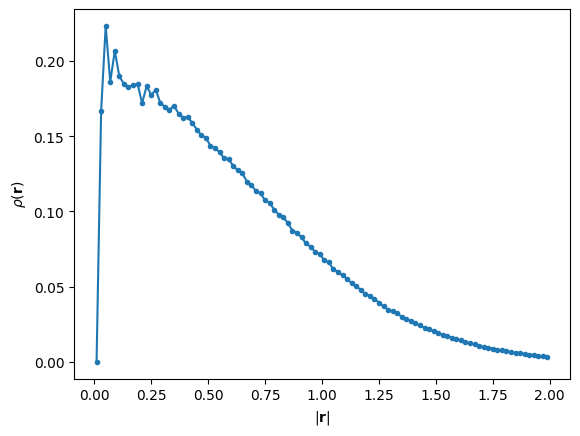

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from vmc_jax import MetropolisJAX
from bose_harmonic_jax import (
  log_wavefunction_jax,
  local_energy_jax,
  drift_force_jax,
  HarmonicParams,
)
from density import radial_onebody_density

base_cycles = 10_000
base_dt = 0.05
diffusion_coefficient = 0.5

number_particles = 100
dim = 3

params_harmonic = HarmonicParams(alpha=0.5)

simulation = MetropolisJAX[HarmonicParams](number_particles, dim)

_, _, _, _, positions = simulation.sample_importance(
  log_wavefunction_jax,
  local_energy_jax,
  drift_force_jax,
  params_harmonic,
  base_dt,
  diffusion_coefficient,
  base_cycles,
)

r, density = radial_onebody_density(positions, 2.0, 100)

plt.plot(r, density, marker=".")
plt.xlabel(r"$|\mathbf{r}|$")
plt.ylabel(r"$\rho(\mathbf{r})$")
plt.show()
